In [1]:
import json
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from tqdm import tqdm
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import random

In [2]:
with open('../data/challenge_set.json', 'r', encoding='utf-8') as f:
    challenge_data = json.load(f)

playlists = challenge_data['playlists']
print(f"Number of playlists: {len(playlists)}")

Number of playlists: 10000


In [7]:
class HybridRecommender:

    def __init__(self):
        self.track_co_occurrences = defaultdict(lambda: defaultdict(int))
        self.track_counts = defaultdict(int)
        self.track_metadata = {}

        self.playlist_name_to_tracks = defaultdict(list)
        self.tfidf_matrix = None
        self.playlist_names = []

        self.total_playlists = 0

        self.popularity_weight = 0.1
        self.name_weight = 5.0
    
    def fit(self, playlists):

        print("Training hybrid recommendation model...")
        self.total_playlists = len(playlists)

        print("Building collaborative filtering model...")
        for playlist in tqdm(playlists):
            track_uris = [track['track_uri'] for track in playlist['tracks']]

            for track in playlist['tracks']:
                track_uri = track['track_uri']
                if track_uri not in self.track_metadata:
                    self.track_metadata[track_uri] = {
                        'name': track['track_name'],
                        'artist': track['artist_name'],
                        'album': track['album_name']
                    }

            for track_uri in track_uris:
                self.track_counts[track_uri] += 1

            for i, track_uri1 in enumerate(track_uris):
                for track_uri2 in track_uris[i+1:]:
                    self.track_co_occurrences[track_uri1][track_uri2] += 1
                    self.track_co_occurrences[track_uri2][track_uri1] += 1

        print("Building content-based model from playlist names...")

        clean_names = []
        
        for playlist in tqdm(playlists):
            if 'name' in playlist and playlist['name'].strip():
                name = self._clean_playlist_name(playlist['name'])
                clean_names.append(name)

                for track in playlist['tracks']:
                    self.playlist_name_to_tracks[name].append(track['track_uri'])
            else:
                clean_names.append("")

        if any(clean_names):
            self.playlist_names = clean_names
            vectorizer = TfidfVectorizer(min_df=2, stop_words='english')

            non_empty_names = [name for name in clean_names if name]
            if non_empty_names:
                self.tfidf_matrix = vectorizer.fit_transform(non_empty_names)
                self.tfidf_feature_names = vectorizer.get_feature_names_out()
                self.name_to_tfidf_idx = {name: i for i, name in enumerate(non_empty_names)}
        
        print("Model training complete!")
    
    def _clean_playlist_name(self, name):
        name = name.lower()
        name = re.sub(f'[{string.punctuation}]', ' ', name)
        name = re.sub(r'\s+', ' ', name).strip()
        return name
    
    def recommend(self, seed_tracks=None, playlist_name=None, n=500, exclude_seeds=True):
        scores = defaultdict(float)

        if seed_tracks:
            for seed_track in seed_tracks:
                if seed_track in self.track_co_occurrences:
                    related_tracks = self.track_co_occurrences[seed_track]

                    for track_uri, count in related_tracks.items():
                        scores[track_uri] += count

        if playlist_name and self.tfidf_matrix is not None:
            clean_name = self._clean_playlist_name(playlist_name)

            vectorizer = TfidfVectorizer(vocabulary=self.tfidf_feature_names)
            name_vector = vectorizer.fit_transform([clean_name])

            if self.tfidf_matrix.shape[0] > 0:
                similarities = cosine_similarity(name_vector, self.tfidf_matrix).flatten()

                for i, name in enumerate(self.playlist_names):
                    if name and name in self.name_to_tfidf_idx:
                        tfidf_idx = self.name_to_tfidf_idx[name]
                        similarity = similarities[tfidf_idx]
                        if similarity > 0:
                            for track_uri in self.playlist_name_to_tracks[name]:
                                scores[track_uri] += similarity * self.name_weight

        if not scores and not seed_tracks:
            top_tracks = sorted(self.track_counts.items(), 
                               key=lambda x: x[1], 
                               reverse=True)
            return [uri for uri, _ in top_tracks[:n]]

        for track_uri in list(scores.keys()):
            scores[track_uri] += self.track_counts.get(track_uri, 0) * self.popularity_weight

        ranked_tracks = sorted(scores.items(), key=lambda x: x[1], reverse=True)

        if exclude_seeds and seed_tracks:
            ranked_tracks = [(uri, score) for uri, score in ranked_tracks 
                            if uri not in seed_tracks]

        return [uri for uri, _ in ranked_tracks[:n]]
    
    def recommend_for_challenge(self, challenge_playlist, n=500):

        seed_tracks = [track['track_uri'] for track in challenge_playlist['tracks']]

        playlist_name = challenge_playlist.get('name', None)

        recommendations = self.recommend(
            seed_tracks=seed_tracks,
            playlist_name=playlist_name,
            n=n+len(seed_tracks),
            exclude_seeds=True
        )

        return recommendations[:n]

In [9]:

def create_train_test_split(playlists, test_size=0.2, random_state=42):
    random.seed(random_state)

    test_indices = random.sample(range(len(playlists)), int(len(playlists) * test_size))

    train_playlists = []
    test_playlists = []
    
    for i, playlist in enumerate(playlists):
        if i in test_indices and len(playlist['tracks']) >= 5:
            test_playlist = playlist.copy()

            num_to_hide = min(10, max(1, len(playlist['tracks']) // 2))

            all_indices = list(range(len(playlist['tracks'])))
            hide_indices = set(random.sample(all_indices, num_to_hide))

            visible_tracks = [t for i, t in enumerate(playlist['tracks']) if i not in hide_indices]
            hidden_tracks = [t for i, t in enumerate(playlist['tracks']) if i in hide_indices]

            test_playlist['visible_tracks'] = visible_tracks
            test_playlist['hidden_tracks'] = hidden_tracks
            test_playlist['tracks'] = visible_tracks
            
            test_playlists.append(test_playlist)
        else:
            train_playlists.append(playlist)
    
    print(f"Split data into {len(train_playlists)} training and {len(test_playlists)} test playlists")
    return train_playlists, test_playlists

train_playlists, test_playlists = create_train_test_split(playlists)

Split data into 8384 training and 1616 test playlists


In [10]:

def evaluate_recommendations(model, test_playlists, k_values=[10, 50, 100, 500]):

    results = {f'precision@{k}': [] for k in k_values}
    results.update({f'recall@{k}': [] for k in k_values})
    results['r_precision'] = []
    
    for playlist in tqdm(test_playlists, desc="Evaluating"):
        hidden_track_uris = [track['track_uri'] for track in playlist['hidden_tracks']]

        recommendations = model.recommend_for_challenge(playlist, n=max(k_values))

        for k in k_values:
            top_k = recommendations[:k]

            hits_at_k = len(set(top_k).intersection(set(hidden_track_uris)))
            precision_at_k = hits_at_k / k
            results[f'precision@{k}'].append(precision_at_k)

            recall_at_k = hits_at_k / len(hidden_track_uris) if hidden_track_uris else 0
            results[f'recall@{k}'].append(recall_at_k)

        r = len(hidden_track_uris)
        top_r = recommendations[:r]
        hits_at_r = len(set(top_r).intersection(set(hidden_track_uris)))
        r_precision = hits_at_r / r if r > 0 else 0
        results['r_precision'].append(r_precision)

    avg_results = {metric: np.mean(values) for metric, values in results.items()}
    
    return avg_results

In [22]:

def tune_model_parameters(train_playlists, validation_playlists, 
                         popularity_weights=[0.1, 0.5, 1.0], 
                         name_weights=[1, 5, 10]):
    results = {}
    
    for pop_weight in popularity_weights:
        for name_weight in name_weights:
            print(f"\nTesting parameters: popularity_weight={pop_weight}, name_weight={name_weight}")

            model = HybridRecommender()
            model.fit(train_playlists)

            model.popularity_weight = pop_weight
            model.name_weight = name_weight

            eval_results = evaluate_recommendations(model, validation_playlists[:100], k_values=[10, 50, 100])

            param_key = f"pop_{pop_weight}_name_{name_weight}"
            results[param_key] = eval_results

            print(f"R-Precision: {eval_results['r_precision']:.4f}")
            print(f"Precision@10: {eval_results['precision@10']:.4f}")
            print(f"Recall@100: {eval_results['recall@100']:.4f}")
    
    return results

In [23]:
train_subset = train_playlists[:8000]
remaining = train_playlists[8000:]
_, validation_playlists = create_train_test_split(remaining, test_size=0.5)


tuning_results = tune_model_parameters(
    train_subset, 
    validation_playlists[:100],
    popularity_weights=[0.1, 0.5],
    name_weights=[3, 7]
)

Split data into 384 training and 0 test playlists

Testing parameters: popularity_weight=0.1, name_weight=3
Training hybrid recommendation model...
Building collaborative filtering model...


100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:03<00:00, 2545.32it/s]


Building content-based model from playlist names...


100%|██████████████████████████████████████████████████████████████████████████| 8000/8000 [00:00<00:00, 217480.62it/s]


Model training complete!


...

Building content-based model from playlist names...


100%|██████████████████████████████████████████████████████████████████████████| 8000/8000 [00:00<00:00, 240000.23it/s]


Model training complete!


Evaluating: 0it [00:00, ?it/s]

R-Precision: nan
Precision@10: nan
Recall@100: nan


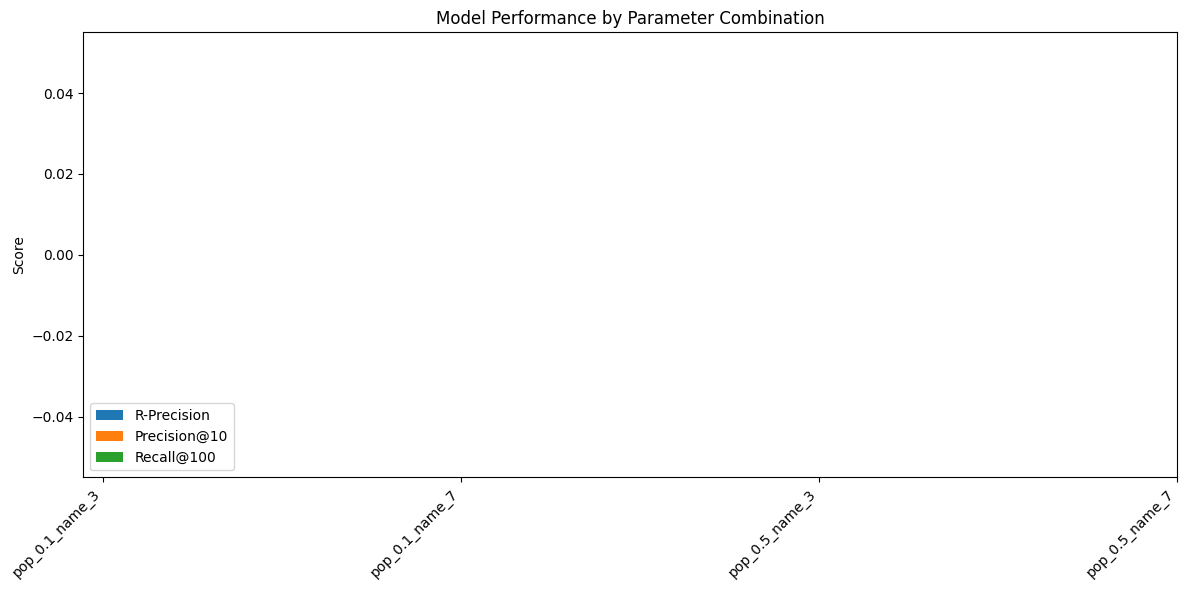

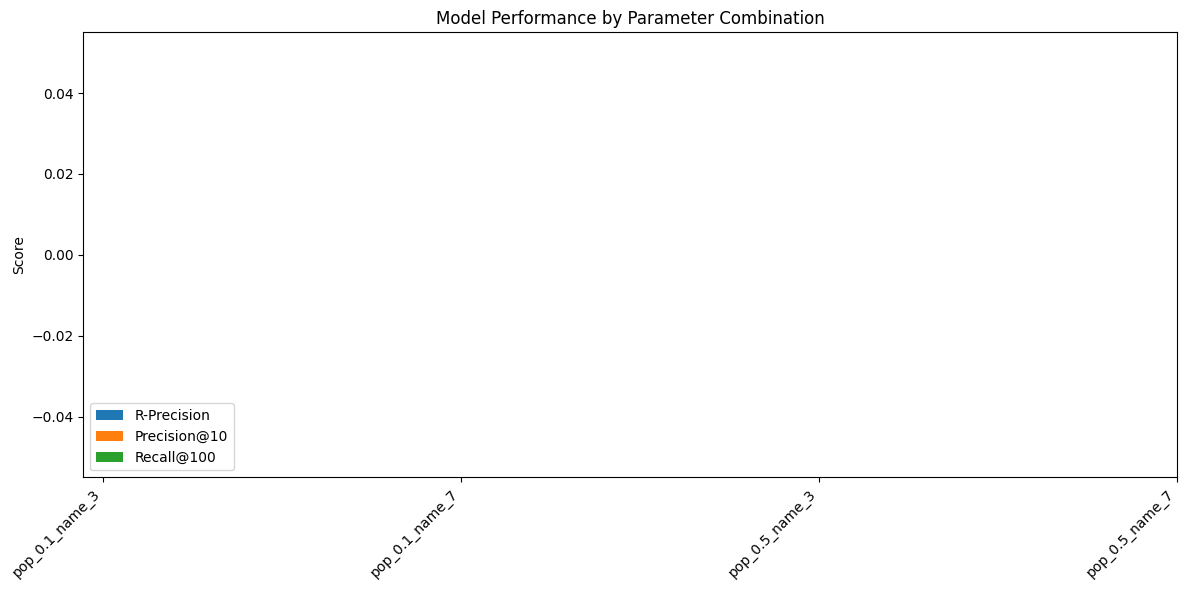

In [13]:
def plot_tuning_results(tuning_results):
    params = list(tuning_results.keys())
    r_precision = [tuning_results[p]['r_precision'] for p in params]
    precision_10 = [tuning_results[p]['precision@10'] for p in params]
    recall_100 = [tuning_results[p]['recall@100'] for p in params]

    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(params))
    width = 0.25

    ax.bar(x - width, r_precision, width, label='R-Precision')
    ax.bar(x, precision_10, width, label='Precision@10')
    ax.bar(x + width, recall_100, width, label='Recall@100')

    ax.set_ylabel('Score')
    ax.set_title('Model Performance by Parameter Combination')
    ax.set_xticks(x)
    ax.set_xticklabels(params, rotation=45, ha='right')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig

plot_tuning_results(tuning_results)

In [14]:
best_params = max(tuning_results.items(), key=lambda x: x[1]['r_precision'])
best_param_key = best_params[0]
best_metrics = best_params[1]

print(f"Best parameter combination: {best_param_key}")
print(f"  R-Precision: {best_metrics['r_precision']:.4f}")
print(f"  Precision@10: {best_metrics['precision@10']:.4f}")
print(f"  Recall@100: {best_metrics['recall@100']:.4f}")

best_pop_weight = float(best_param_key.split('_')[1])
best_name_weight = float(best_param_key.split('_')[3])

final_model = HybridRecommender()
final_model.fit(train_playlists)
final_model.popularity_weight = best_pop_weight
final_model.name_weight = best_name_weight

test_results = evaluate_recommendations(final_model, test_playlists[:100])

print("\nFinal model performance on test set:")
for metric, value in sorted(test_results.items()):
    print(f"{metric}: {value:.4f}")

Best parameter combination: pop_0.1_name_3
  R-Precision: nan
  Precision@10: nan
  Recall@100: nan
Training hybrid recommendation model...
Building collaborative filtering model...


100%|████████████████████████████████████████████████████████████████████████████| 8384/8384 [00:03<00:00, 2597.75it/s]


Building content-based model from playlist names...


100%|██████████████████████████████████████████████████████████████████████████| 8384/8384 [00:00<00:00, 232685.39it/s]


Model training complete!


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 53.76it/s]


Final model performance on test set:
precision@10: 0.0100
precision@100: 0.0039
precision@50: 0.0054
precision@500: 0.0015
r_precision: 0.0150
recall@10: 0.0500
recall@100: 0.1950
recall@50: 0.1350
recall@500: 0.3650


In [15]:
def display_recommendations(model, playlist, n=10):
    seed_tracks = [track['track_uri'] for track in playlist['tracks']]

    playlist_name = playlist.get('name', 'No Name')
    
    print(f"Playlist: {playlist_name}")
    print(f"Number of seed tracks: {len(seed_tracks)}")

    print("\nSeed tracks:")
    for i, track in enumerate(playlist['tracks'][:5]):  # Show first 5 seeds
        print(f"  {i+1}. {track['track_name']} by {track['artist_name']}")
    if len(playlist['tracks']) > 5:
        print(f"  ... and {len(playlist['tracks']) - 5} more")

    rec_uris = model.recommend_for_challenge(playlist, n=n)

    print("\nRecommendations:")
    for i, uri in enumerate(rec_uris):
        if uri in model.track_metadata:
            track_info = model.track_metadata[uri]
            print(f"  {i+1}. {track_info['name']} by {track_info['artist']}")
        else:
            print(f"  {i+1}. {uri} (metadata not available)")

print("Recommendations with the best model parameters:")
for i in range(3):
    print(f"\nExample {i+1}:")
    display_recommendations(final_model, test_playlists[i])
    print("-" * 80)

Recommendations with the best model parameters:

Example 1:
Playlist: lit 2.0
Number of seed tracks: 3

Seed tracks:
  1. Limelight - NGHTMRE Remix by Just A Gent
  2. Carmalude by Carmada
  3. Stay (with Alessia Cara) by Zedd

Recommendations:
  1. Bounce Back by Big Sean
  2. Gold Digger by Kanye West
  3. Jumpman by Drake
  4. No Problem (feat. Lil Wayne & 2 Chainz) by Chance The Rapper
  5. Needed Me by Rihanna
  6. Come Get Her by Rae Sremmurd
  7. Ni**as In Paris by JAY Z
  8. pick up the phone by Young Thug
  9. Fake Love by Drake
  10. 2 Phones by Kevin Gates
--------------------------------------------------------------------------------

Example 2:
Playlist: stubborn love
Number of seed tracks: 3

Seed tracks:
  1. Thunder Clatter by Wild Cub
  2. Rhythm Of Love by Plain White T's
  3. Landslide by Oh Wonder

Recommendations:
  1. Adore You by Miley Cyrus
  2. More Than Miles by Brantley Gilbert
  3. Trouble by Coldplay
  4. Your Grace Is Enough by Chris Tomlin
  5. Thinking 

In [20]:
import os
import pickle
import json

def create_submission_sample(challenge_data, model, output_file, sample_size=10):
    print(f"Generating recommendations for {sample_size} sample playlists...")
    
    with open(output_file, 'w') as f:
        f.write("team_info,Tonalytics,your.email@example.com\n")

        for playlist in challenge_data['playlists'][:sample_size]:
            pid = playlist['pid']
            recommendations = model.recommend_for_challenge(playlist, n=500)

            f.write(f"{pid},{','.join(recommendations)}\n")
    
    print(f"Sample submission file created: {output_file}")

os.makedirs('../submissions', exist_ok=True)
sample_file = '../submissions/hybrid_recommender_sample.csv'
create_submission_sample(challenge_data, final_model, sample_file)

print("\nTo generate the full submission, run the final_recommender.py script with the best parameters.")

best_params = {
    'popularity_weight': final_model.popularity_weight,
    'name_weight': final_model.name_weight
}

params_file = '../models/best_parameters.json'
with open(params_file, 'w') as f:
    json.dump(best_params, f)
print(f"Best parameters saved to {params_file}")

Generating recommendations for 10 sample playlists...
Sample submission file created: ../submissions/hybrid_recommender_sample.csv

To generate the full submission, run the final_recommender.py script with the best parameters.
Best parameters saved to ../models/best_parameters.json
